In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import Waveform1PAT1R, FastKerrEccentricEquatorialFlux
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R

from tqdm import tqdm

## Simple waveform example

In [2]:
# --- Define Parameters ---
m1 = 1e6       # primary mass [solar masses]
m2 = 1e4      # secondary mass [solar masses]
chi1  = 0.1
a = chi1 # primary spin chi1 (dimensionless)
p0 = 12.0      # initial orbital separation [M]
theta = np.pi / 3.0   # polar viewing angle [rad]
phi   = 0.0           # azimuthal viewing angle [rad]
chi2  = 0.1 # secondary spin

dt = 5.   # time step [s]
T  = 1    # total duration [yr]

In [3]:
WF1PAT1R = Waveform1PAT1R()
h1PAT1R = WF1PAT1R(m1, m2, chi1, p0, theta, phi, chi2, dt=dt, T=T)
print(len(h1PAT1R))

27892


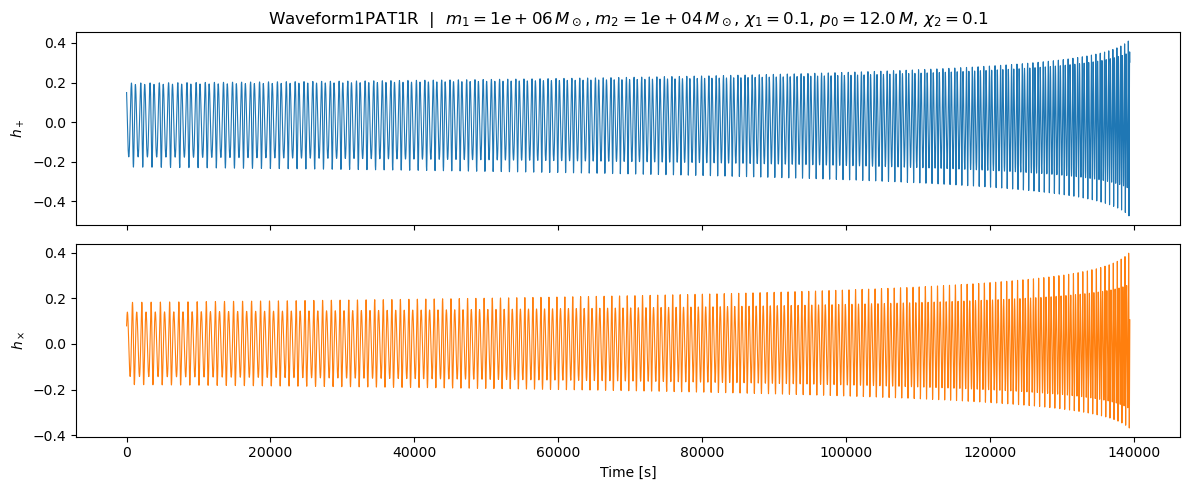

In [4]:
t1PA = np.arange(len(h1PAT1R)) * dt  # time array in seconds

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t1PA, h1PAT1R.real, lw=0.8)
axes[0].set_ylabel(r"$h_+$")
axes[0].set_title(
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2:.0e}\,M_\odot$, "
    rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

axes[1].plot(t1PA, -h1PAT1R.imag, lw=0.8, color="C1")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

## Random sample tests

In [8]:
ode = Trajectory1PAT1R()

min_p = ode._min_p + 0.5;
max_p = ode._max_p

min_logm = -1.0
max_logm = 10.0

min_chi1 = ode._min_chi1
max_chi1 = ode._max_chi1

min_chi2 = ode._min_chi2
max_chi2 = ode._max_chi2

N_TESTS = 2000
dt = 5.   # time step [s]
T  = 100    # total duration [yr]

In [9]:
#p = np.random.uniform(min_p, max_p, N_TESTS)
logm1 = np.random.uniform(min_logm, max_logm, N_TESTS)
logm2 = np.random.uniform(min_logm, max_logm, N_TESTS)
m1 = np.array([10.**np.max([logm1[i], logm2[i]]) for i in range(N_TESTS)])
m2 = np.array([10.**np.min([logm1[i], logm2[i]]) for i in range(N_TESTS)])
nu = m1 * m2 / (m1 + m2)**2.
chi1 = np.random.uniform(min_chi1, max_chi1, N_TESTS)
chi2 = np.random.uniform(min_chi2, max_chi2, N_TESTS)

p = np.array([np.random.uniform(*ode.bounds_p(0.0, 1.0, chi1[i], p_buffer=[0.01,0.0])) for i in range(N_TESTS)])

In [7]:
np.log10(m1[0]/m2[0])

np.float64(6.181639356109727)

In [8]:
i = 0
from time import perf_counter
start = perf_counter()
h1PAT1R = WF1PAT1R(m1[i], m2[i], chi1[i], p[i], theta, phi, chi2[i], dt=dt, T=35)
end = perf_counter()
print(end-start)

56.704805751000094


In [ ]:
failed_indices = []
signal_length_arr = [] 
WF1PAT1R = Waveform1PAT1R()

from time import perf_counter

for i in tqdm(range(N_TESTS)):
    try:
        #print(m1[i], m2[i], chi1[i], p[i], theta, phi, chi2[i], dt, T)
        #start = perf_counter()
        h1PAT1R = WF1PAT1R(m1[i], m2[i], chi1[i], p[i], theta, phi, chi2[i], dt=dt, T=T)
        #print(perf_counter()-start)
        signal_length_arr.append(dt*len(h1PAT1R))
    except (ValueError, AssertionError) as e:
        print(f"  -> ValueError at i={i}: {e}")
        failed_indices.append(i)

print(f"\nFailed indices: {failed_indices}")


  0%|                                                                                | 0/2000 [00:00<?, ?it/s]

In [ ]:
mask = np.ones(N_TESTS, dtype=bool)
mask[failed_indices] = False

nu_failed = nu[~mask]
chi1_failed = chi1[~mask]
chi2_failed = chi2[~mask]
p_failed = p[~mask]

nu_success = nu[mask]
chi1_success = chi1[mask]
chi2_success = chi2[mask]
p_success = p[mask]

In [ ]:
fig, axs = plt.subplots(2,3,figsize=(15,10))

axs[0,0].scatter(np.log10(nu_failed), chi1_failed, color='red', label='Failed', s=10)
axs[0,0].scatter(np.log10(nu_success), chi1_success, color='green', label='Succeeded', s=10)
axs[0,0].set_xlabel('log10(nu)')
axs[0,0].set_ylabel('chi1')
axs[0,0].legend()

axs[0,1].scatter(np.log10(nu_failed), chi2_failed, color='red', label='Failed', s=10)
axs[0,1].scatter(np.log10(nu_success), chi2_success, color='green', label='Succeeded', s=10)
axs[0,1].set_xlabel('log10(nu)')
axs[0,1].set_ylabel('chi2')
axs[0,1].legend()

axs[0,2].scatter(np.log10(nu_failed), p_failed, color='red', label='Failed', s=10)
axs[0,2].scatter(np.log10(nu_success), p_success, color='green', label='Succeeded', s=10)
axs[0,2].set_xlabel('log10(nu)')
axs[0,2].set_ylabel('p0')
axs[0,2].legend()

axs[1,0].scatter(chi1_failed, chi2_failed, color='red', label='Failed', s=10)
axs[1,0].scatter(chi1_success, chi2_success, color='green', label='Succeeded', s=10)
axs[1,0].set_xlabel('chi1')
axs[1,0].set_ylabel('chi2')
axs[1,0].legend()

axs[1,1].scatter(chi1_failed, p_failed, color='red', label='Failed', s=10)
axs[1,1].scatter(chi1_success, p_success, color='green', label='Succeeded', s=10)
axs[1,1].set_xlabel('chi1')
axs[1,1].set_ylabel('p0')
axs[1,1].legend()

axs[1,2].scatter(chi2_failed, p_failed, color='red', label='Failed', s=10)
axs[1,2].scatter(chi2_success, p_success, color='green', label='Succeeded', s=10)
axs[1,2].set_xlabel('chi2')
axs[1,2].set_ylabel('p0')
axs[1,2].legend()

plt.show()
plt.savefig("pass_fail_plot.png")

In [ ]:
min(p), max(p)

In [ ]:
plt.hist(signal_length_arr)
plt.xlabel("Signal length [s]")

In [ ]:
signal_length_points = np.array(signal_length_arr)/dt;
plt.hist(signal_length_points)
plt.xscale('log')
plt.xlabel("Signal length [grid points]")

In [ ]:
plt.scatter(nu, signal_length_arr)
plt.xscale('log')
plt.xlabel(r'$\nu$')
plt.ylabel(r"Signal length [s]")

## Memory benchmark

  T=1.0000 yr  ->  211.12 MB
  T=2.0000 yr  ->  403.78 MB
  T=4.0000 yr  ->  788.96 MB
  T=8.0000 yr  ->  1558.78 MB
  T=16.0000 yr  ->  3099.82 MB
  T=32.0000 yr  ->  6181.66 MB

Fit: memory ~ 206.9707 * T^0.9761 MB
Estimated memory for T=100 yr: 18539.5 MB  (18.10 GB)


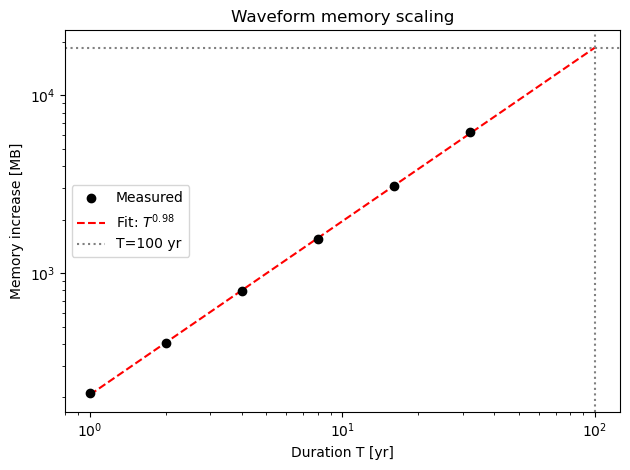

In [11]:
import numpy as np
import psutil
import os
import matplotlib.pyplot as plt

def measure_memory_waveform(T_yr, dt, m1, m2, chi1, p, theta, phi, chi2):
    """Generate a single waveform and return peak memory increase in MB."""
    process = psutil.Process(os.getpid())
    
    # Baseline before allocation
    mem_before = process.memory_info().rss
    
    wf = Waveform1PAT1R()
    h  = wf(m1, m2, chi1, p, theta, phi, chi2, dt=dt, T=T_yr)
    
    mem_after = process.memory_info().rss
    
    # Hold reference to h so it isn't GC'd before measurement
    del h
    
    return (mem_after - mem_before) / 1024**2  # bytes -> MB

# Fix a representative parameter set
dt = 5.0
m1, m2        = 1e10, 1e-1
chi1, p       = 0.1, 8.0
theta, phi, chi2 = 1.0, 1.0, 0.3

# Sweep over durations (keep short to stay within memory)
T_test_yr = [1, 2, 4, 8, 16, 32]
mem_MB    = []

for T in T_test_yr:
    mem = measure_memory_waveform(T, dt, m1, m2, chi1, p, theta, phi, chi2)
    print(f"  T={T:.4f} yr  ->  {mem:.2f} MB")
    mem_MB.append(mem)

T_arr   = np.array(T_test_yr)
mem_arr = np.array(mem_MB)

# Fit log-log: memory ~ a * T^b
b, log_a = np.polyfit(np.log10(T_arr), np.log10(mem_arr), 1)
a = 10**log_a
print(f"\nFit: memory ~ {a:.4f} * T^{b:.4f} MB")

# Extrapolate to 100 yr
T_target   = 100.0
mem_extrap = a * T_target**b
print(f"Estimated memory for T=100 yr: {mem_extrap:.1f} MB  ({mem_extrap/1024:.2f} GB)")

# Plot
T_plot = np.logspace(np.log10(T_arr.min()), np.log10(T_target), 200)
fig, ax = plt.subplots()
ax.scatter(T_arr, mem_arr, color='black', zorder=5, label='Measured')
ax.plot(T_plot, a * T_plot**b, 'r--', label=f'Fit: $T^{{{b:.2f}}}$')
ax.axvline(T_target, color='grey', linestyle=':', label='T=100 yr')
ax.axhline(mem_extrap, color='grey', linestyle=':')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Duration T [yr]')
ax.set_ylabel('Memory increase [MB]')
ax.set_title('Waveform memory scaling')
ax.legend()
plt.tight_layout()
plt.savefig("memory_scaling.png")